In [21]:
from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

data=load_wine()
X_train,X_test,y_train,y_test=train_test_split(
    data.data,data.target,test_size=0.2,random_state=35)
depths=[1,3,5,10,None]
train_acc=[]
test_acc=[]
for depth in depths:
  model=DecisionTreeClassifier(max_depth=depth,random_state=35)
  model.fit(X_train,y_train)
  train_acc.append(model.score(X_train,y_train))
  test_acc.append(model.score(X_test,y_test))
  print("Train Accuracy:",model.score(X_train,y_train)," with depth",depth)
  print("Test Accuracy:",model.score(X_test,y_test)," with depth",depth)

Train Accuracy: 0.7112676056338029  with depth 1
Test Accuracy: 0.6388888888888888  with depth 1
Train Accuracy: 0.9929577464788732  with depth 3
Test Accuracy: 0.8611111111111112  with depth 3
Train Accuracy: 1.0  with depth 5
Test Accuracy: 0.8611111111111112  with depth 5
Train Accuracy: 1.0  with depth 10
Test Accuracy: 0.8611111111111112  with depth 10
Train Accuracy: 1.0  with depth None
Test Accuracy: 0.8611111111111112  with depth None


In [22]:
from sklearn.ensemble import AdaBoostClassifier

boost_model=AdaBoostClassifier(n_estimators=50,random_state=35)
boost_model.fit(X_train,y_train)
model=DecisionTreeClassifier(max_depth=3,random_state=35)
model.fit(X_train,y_train)
print("Boosted Train Accuracy:",boost_model.score(X_train,y_train))
print("Boosted Test Accuracy:",boost_model.score(X_test,y_test))
print("Single Decision Tree Train Accuracy:",model.score(X_train,y_train)," with depth",3)
print("Single Decision Tree Test Accuracy:",model.score(X_test,y_test)," with depth",3)

Boosted Train Accuracy: 1.0
Boosted Test Accuracy: 0.9166666666666666
Single Decision Tree Train Accuracy: 0.9929577464788732  with depth 3
Single Decision Tree Test Accuracy: 0.8611111111111112  with depth 3


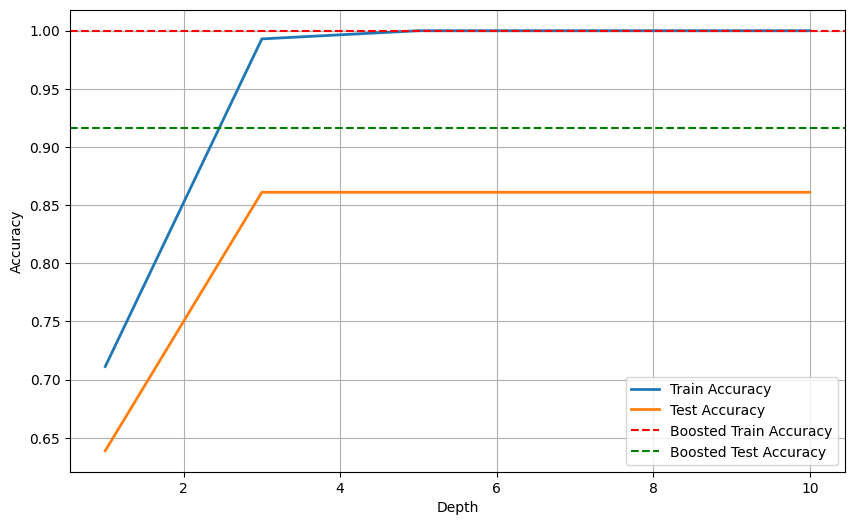

In [27]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot(depths,train_acc,label="Train Accuracy",linewidth=2)
plt.plot(depths,test_acc,label="Test Accuracy",linewidth=2)
plt.axhline(y=boost_model.score(X_train,y_train),color='r',
            linestyle='--',label='Boosted Train Accuracy')
plt.axhline(y=boost_model.score(X_test,y_test),
            color='g',linestyle='--',label='Boosted Test Accuracy')
plt.xlabel("Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

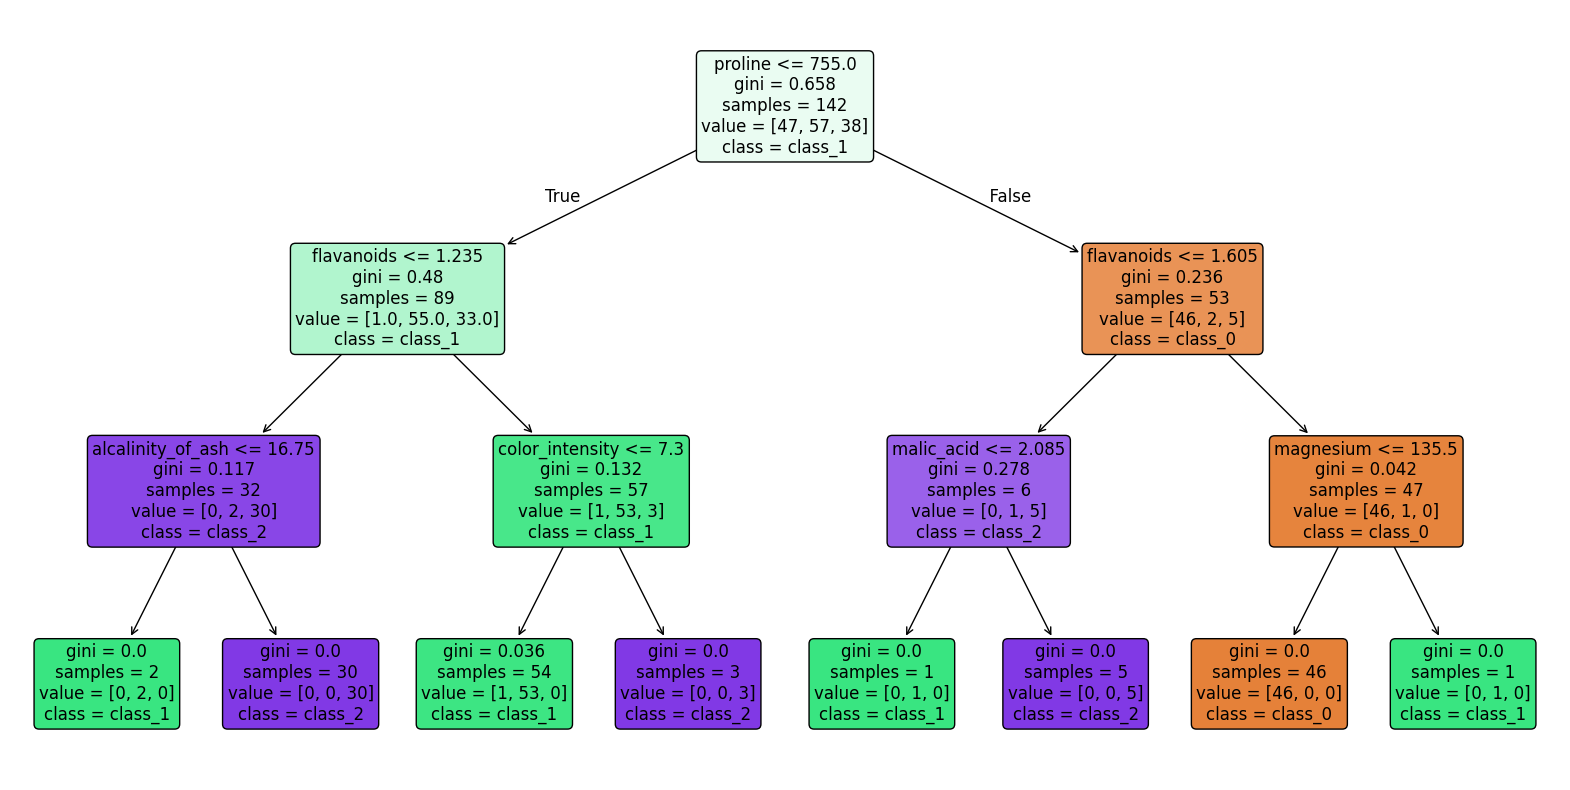

In [30]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

model_to_viz=DecisionTreeClassifier(max_depth=3, random_state=35)
model_to_viz.fit(X_train,y_train)

plt.figure(figsize=(20,10))
plot_tree(model_to_viz,feature_names=data.feature_names,
          class_names=data.target_names,filled=True,
          rounded=True,fontsize=12)
plt.show()

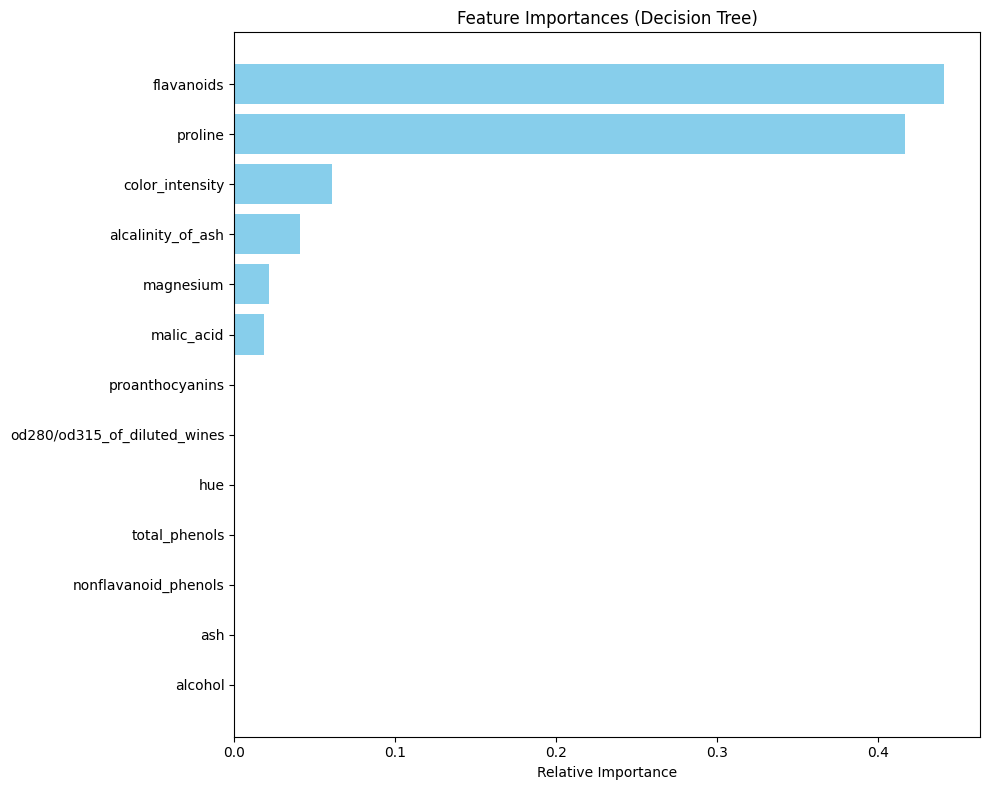

In [35]:
import numpy as np
importances=model.feature_importances_
feature_names=data.feature_names
indices=np.argsort(importances)
plt.figure(figsize=(10, 8))
plt.title("Feature Importances (Decision Tree)")
plt.barh(range(len(indices)),importances[indices],color='skyblue',align='center')
plt.yticks(range(len(indices)),[feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()

In [40]:
from sklearn.ensemble import RandomForestClassifier
dt_model=DecisionTreeClassifier(max_depth=3, random_state=35)
ada_model=AdaBoostClassifier(n_estimators=50, random_state=35)
rf_model=RandomForestClassifier(n_estimators=100, random_state=35)

dt_model.fit(X_train, y_train)
ada_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
models={"Decision Tree": dt_model,"AdaBoost": ada_model,
        "Random Forest": rf_model}
for name, m in models.items():
  print(name,"Train Accuracy:",m.score(X_train, y_train),
        "and Test Accuracy:",m.score(X_test, y_test))

Decision Tree Train Accuracy: 0.9929577464788732 and Test Accuracy: 0.8611111111111112
AdaBoost Train Accuracy: 1.0 and Test Accuracy: 0.9166666666666666
Random Forest Train Accuracy: 1.0 and Test Accuracy: 0.9722222222222222


Boosted Train Accuracy: 1.0
Boosted Test Accuracy: 0.9166666666666666
Boosted Train Accuracy: 1.0
Boosted Test Accuracy: 0.9166666666666666
Boosted Train Accuracy: 1.0
Boosted Test Accuracy: 1.0
Boosted Train Accuracy: 1.0
Boosted Test Accuracy: 0.9722222222222222


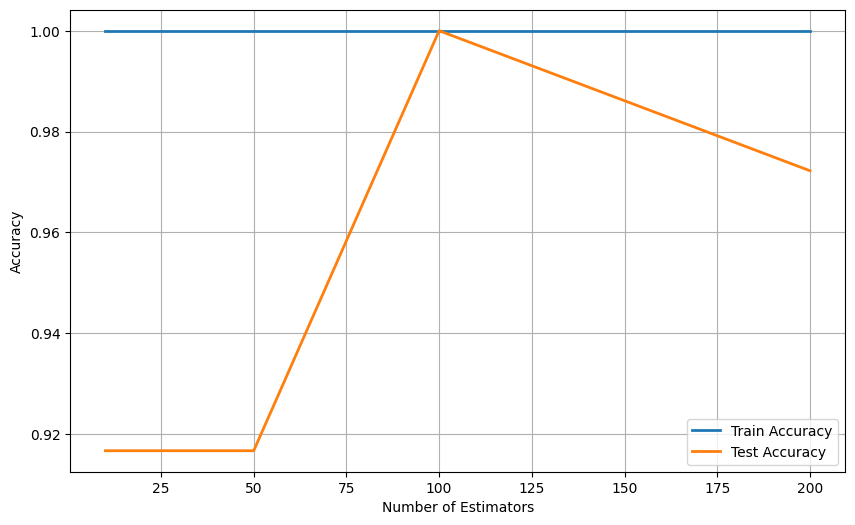

In [42]:
number_of_estimators=[10,50,100,200]
trainAda_acc=[]
testAda_acc=[]
for n in number_of_estimators:
  diff_est_model=AdaBoostClassifier(n_estimators=n,random_state=35)
  diff_est_model.fit(X_train,y_train)
  trainAda_acc.append(diff_est_model.score(X_train,y_train))
  testAda_acc.append(diff_est_model.score(X_test,y_test))
  print("Boosted Train Accuracy:",diff_est_model.score(X_train,y_train))
  print("Boosted Test Accuracy:",diff_est_model.score(X_test,y_test))
plt.figure(figsize=(10,6))
plt.plot(number_of_estimators,trainAda_acc,label="Train Accuracy",linewidth=2)
plt.plot(number_of_estimators,testAda_acc,label="Test Accuracy",linewidth=2)
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

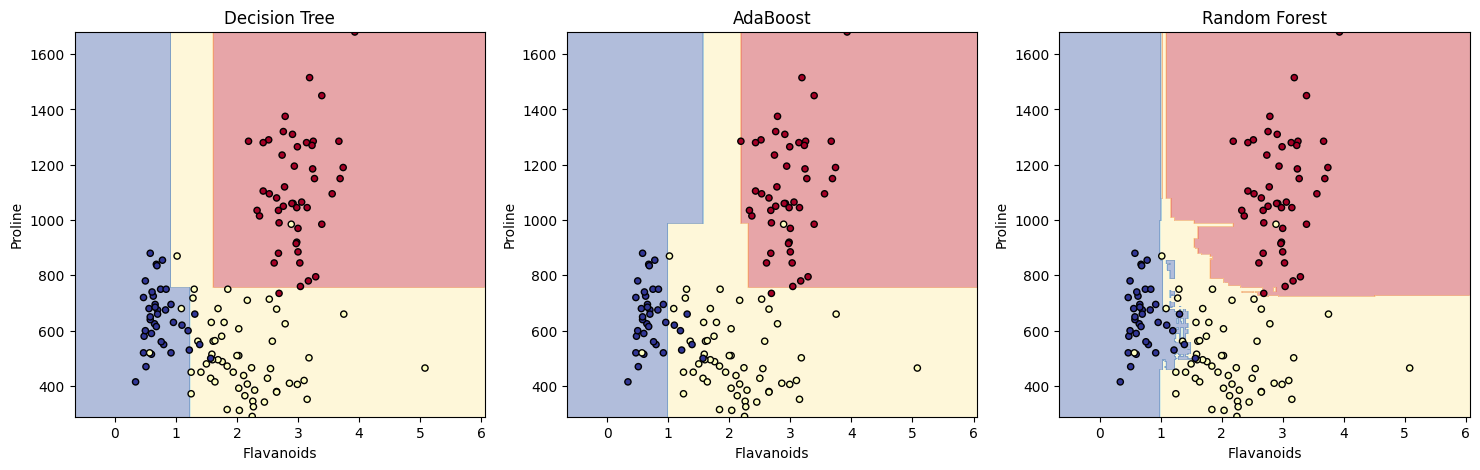

In [44]:
import numpy as np
import matplotlib.pyplot as plt
feature_indices=[6, 12]
X_vis=X_train[:,feature_indices]
y_vis=y_train
h=.02
x_min,x_max=X_vis[:,0].min()-1,X_vis[:,0].max()+1
y_min,y_max=X_vis[:,1].min()-1,X_vis[:,1].max()+1
xx,yy=np.meshgrid(np.arange(x_min,x_max,h),np.arange(y_min,y_max,h))
titles=['Decision Tree','AdaBoost','Random Forest']
models=[dt_model,ada_model,rf_model]
fig,sub=plt.subplots(1,3,figsize=(18,5))
for clf,title,ax in zip(models,titles,sub.flatten()):
    clf_vis=clf.__class__(**clf.get_params())
    clf_vis.fit(X_vis,y_vis)
    Z=clf_vis.predict(np.c_[xx.ravel(),yy.ravel()])
    Z=Z.reshape(xx.shape)
    ax.contourf(xx,yy,Z,alpha=0.4,cmap=plt.cm.RdYlBu)
    ax.scatter(X_vis[:,0],X_vis[:,1],c=y_vis,s=20,
               edgecolor='k',cmap=plt.cm.RdYlBu)
    ax.set_title(title)
    ax.set_xlabel('Flavanoids')
    ax.set_ylabel('Proline')
plt.show()